Step 1: Load the Dataset

In [1]:
import pandas as pd

# Load Excel file
df = pd.read_excel("kmeans_practice_data.xlsx")

# View first rows
print(df.head())

   Feature1  Feature2
0     19.28     19.14
1     19.44     23.51
2     19.36     12.51
3     21.66     18.66
4     18.92     20.58


Step 2: Visualize Raw Data

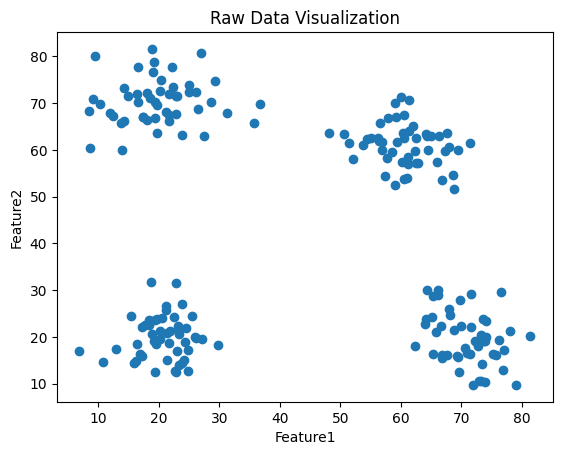

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["Feature1"], df["Feature2"])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Raw Data Visualization")
plt.show()

Step 3: Apply K-Means

In [4]:
from sklearn.cluster import KMeans

# Try with K = 4 (we’ll justify later)
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)

df["Cluster"] = kmeans.fit_predict(df)

print(df.head())

   Feature1  Feature2  Cluster
0     19.28     19.14        2
1     19.44     23.51        2
2     19.36     12.51        2
3     21.66     18.66        2
4     18.92     20.58        2


Step 4: Visualize Clusters

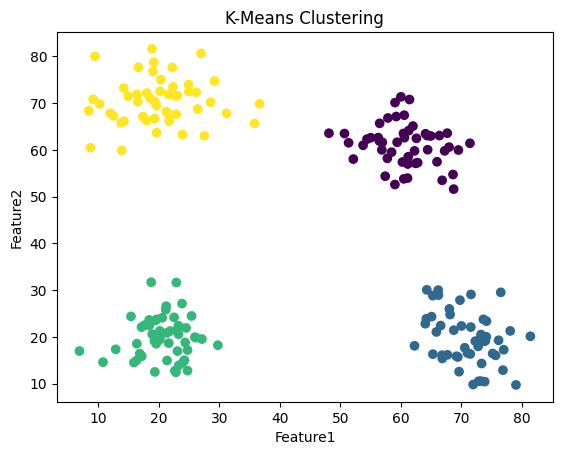

In [5]:
plt.scatter(df["Feature1"], df["Feature2"], c=df["Cluster"])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("K-Means Clustering")
plt.show()

Step 5: Plot Centroids

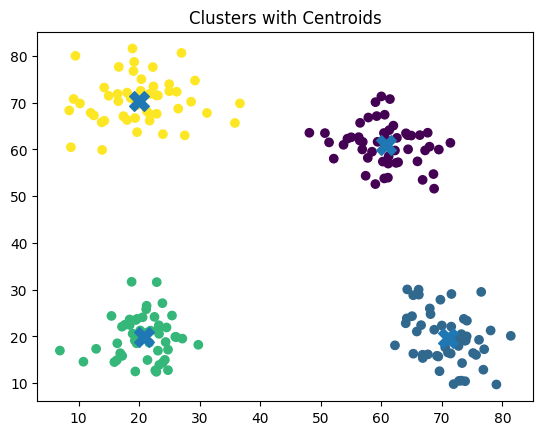

In [6]:
centroids = kmeans.cluster_centers_

plt.scatter(df["Feature1"], df["Feature2"], c=df["Cluster"])
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)

plt.title("Clusters with Centroids")
plt.show()

Step 6: Find Optimal K (Elbow Method)

c:\Users\hpvan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\hpvan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\hpvan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\hpvan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

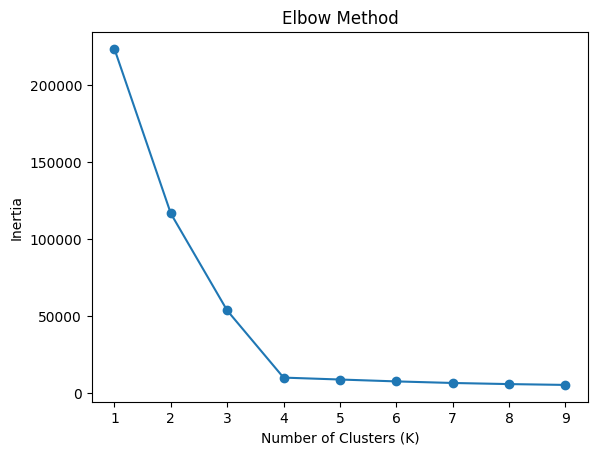

In [8]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[["Feature1", "Feature2"]])
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()